# Supervised vs Unsupervised Learning

1. Supervised Learning is a method of finding a function that when given input x gives output y, the process is about using data that has the inputs x and the actual output y so that using the inputs x in a function give as close of a prediction of what the output y would be. Supervised means that the data has both the input and the output which is also called labelled data. The labelled data allows us to compare our result (prediction) with the actual output so that we know how close we are with this function, and also we tune this function using the error (actual-predicted, could be square or absolute, so errors don't cancel each other out) so that every time we retrain we are getting closer and closer. Mathematically, given {x,y} find f(x) = y.

2. Unsupervised Learning is a method of finding some pattern in data and that pattern is not provided as an output in the data, so basically it is only the x that we have. Now the goal here could be multiple things, it could be finding a grouping (usually called clustering) of the data entries meaning placing close entries together in a cluster and the goal being having a low error (here it is calculated by the total distances of the entires from their assigned centroids(center of a cluster)), or it could be something like dimensionality reduction which is a way removing features that are unneeded (unneeded usually means does not explain a lot or any variability in the data) with the most famous of the methods being pca, this calculates something called the principal component of each feature and then you take the features that explain lets say 90% of the variability starting with the largest so that you can use fewer features. Mathematically, given {x} find some pattern in the data. # Look at the mathematical representation of unsupervised

Main mathematical forms of unsupervised learning:

1. Clustering:
   c_i = f(x_i)

   Example, K-means:
   min Σ_i min_k ||x_i - μ_k||²

2. Dimensionality Reduction:
   z = f(x)

   where x ∈ R^d and z ∈ R^k, with k < d.
   PCA can be written as:
   z = Wᵀx

3. Density Estimation:
   x_i ~ p(x)
   Learn:
   p̂(x) ≈ p(x)

4. Latent Variable Models:
   x ~ p(x | z)

   with:
   p(x) = ∫ p(x | z)p(z) dz

5. Representation Learning:
   z = f(x)

   Autoencoder:
   z = encoder(x)
   x̂ = decoder(z)

   Minimize:
   ||x - x̂||²

6. Association Rule Learning:
   A → B

   Confidence:
   P(B | A)

   Support:
   P(A ∩ B)

7. Anomaly Detection:
   s(x) = f(x)

   If:
   s(x) > τ

   then x is considered an anomaly.


# IMDB Sentiment Classification with Logistic Regression

This section trains a binary sentiment classifier using the IMDB dataset and the custom preprocessor, regex tokenizer, and TF-IDF vectorization logic implemented in the earlier parts of the project. The split happens before the vectorizer is fitted, so vocabulary selection and IDF values are learned from training data only. Exact duplicate reviews are removed before splitting to prevent the same review from leaking into both sets.

Stop-word removal is disabled because words such as `not`, `no`, and `never` carry important sentiment information. Stemming is also disabled so the learned coefficients remain easy to interpret.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Locate the earlier preprocessing, tokenization, and vectorization work.
current_path = Path.cwd().resolve()
repository_root = next(
    (path for path in (current_path, *current_path.parents)
     if (path / "phase-1-machine-learning-nlp").is_dir()),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
part_06 = phase_1 / "06-vectorization"
sys.path.insert(0, str(part_02 / "src"))
sys.path.insert(0, str(part_06 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize
from vectorizer import CustomTfidfVectorizer

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
imdb = pd.read_csv(imdb_path)
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb.columns):
    raise KeyError(f"The IMDB dataset must contain {sorted(required_columns)}.")
if imdb[list(required_columns)].isna().any().any():
    raise ValueError("The IMDB review and sentiment columns cannot contain missing values.")
if not set(imdb["sentiment"].unique()).issubset({"negative", "positive"}):
    raise ValueError("Unexpected sentiment label found in the IMDB dataset.")
if imdb.groupby("review")["sentiment"].nunique().gt(1).any():
    raise ValueError("Identical reviews with conflicting labels were found.")

original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="review").reset_index(drop=True)
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})

print(f"Dataset path: {imdb_path}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} exact duplicates removed)")
print(imdb["sentiment"].value_counts().sort_index())


Dataset path: /home/jadkandah/progressSoft_internship/phase-1-machine-learning-nlp/02-preprocessing-tokenization/data/IMDB Dataset.csv
Reviews retained: 49,582 (418 exact duplicates removed)
sentiment
negative    24698
positive    24884
Name: count, dtype: int64


In [2]:
# Use the reusable custom vectorizer from the previous vectorization work.
text_vectorizer = CustomTfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=regex_tokenize,
    min_df=5,
    max_df=0.95,
    max_features=30_000,
)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    imdb["review"], imdb["label"], test_size=0.20,
    random_state=42, stratify=imdb["label"],
)

sentiment_model = Pipeline([
    ("tfidf", text_vectorizer),
    ("logistic_regression", LogisticRegression(
        C=4.0, solver="liblinear", max_iter=1_000, random_state=42
    )),
])
sentiment_model.fit(X_train, y_train)

print(f"Training reviews: {len(X_train):,}")
print(f"Test reviews: {len(X_test):,}")
print(f"Learned vocabulary size: {len(text_vectorizer.vocabulary_):,}")


Training reviews: 39,665
Test reviews: 9,917
Learned vocabulary size: 30,000


,test_score
accuracy,0.8875
precision,0.8796
recall,0.8987
f1,0.8891
roc_auc,0.9536


Classification report:
              precision    recall  f1-score   support

    negative     0.8957    0.8761    0.8858      4940
    positive     0.8796    0.8987    0.8891      4977

    accuracy                         0.8875      9917
   macro avg     0.8877    0.8874    0.8874      9917
weighted avg     0.8876    0.8875    0.8874      9917



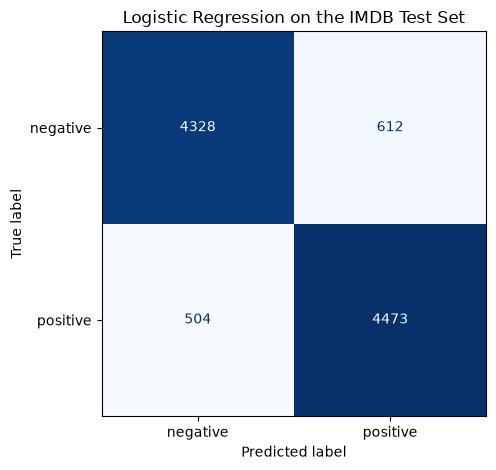

In [4]:
test_predictions = sentiment_model.predict(X_test)
test_positive_probabilities = sentiment_model.predict_proba(X_test)[:, 1]

test_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, test_predictions),
    "precision": precision_score(y_test, test_predictions),
    "recall": recall_score(y_test, test_predictions),
    "f1": f1_score(y_test, test_predictions),
    "roc_auc": roc_auc_score(y_test, test_positive_probabilities),
}, name="test_score").to_frame()

display(test_metrics.style.format("{:.4f}"))
print("Classification report:")
print(classification_report(
    y_test, test_predictions, target_names=["negative", "positive"], digits=4
))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=["negative", "positive"],
    cmap="Blues", colorbar=False,
)
plt.title("Logistic Regression on the IMDB Test Set")
plt.tight_layout()
plt.show()
